# 08 - Evaluate Per-Crop Disease Classifiers

Stage 8: Evaluate trained disease classifiers on their held-out test sets.

Automatically skips any crop whose model file doesn't exist yet -- so this
runs fine right now with only Cotton and Tomato trained, and you can
re-run it as you finish the other three crops without editing anything.

Reports per crop:
  - classification_report (precision/recall/F1 per disease class)
  - macro-F1 (watch this over raw accuracy, given class imbalance)
  - confusion matrix, saved as confusion_matrix_<crop>.png

Install deps:
    pip install scikit-learn matplotlib seaborn --break-system-packages

## Imports & Configuration

In [8]:
import json
from pathlib import Path

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_ROOT = Path("disease_dataset")
MODELS_DIR = Path("models")
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CROPS = ["Cotton", "Groundnut", "Pepper Bell", "Potato", "Tomato"]

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

## `load_model_and_labels`

In [9]:
def load_model_and_labels(crop_slug):
    model_path = MODELS_DIR / f"disease_{crop_slug}.pth"
    labels_path = MODELS_DIR / f"disease_{crop_slug}_labels.json"
    if not model_path.exists() or not labels_path.exists():
        return None, None
    with open(labels_path) as f:
        classes = json.load(f)
    model = timm.create_model("efficientnet_b2", pretrained=False, num_classes=len(classes))
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model, classes

## `evaluate_test_set`

In [10]:
def evaluate_test_set(model, classes, test_dir):
    y_true, y_pred = [], []
    for class_idx, class_name in enumerate(classes):
        class_dir = test_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.iterdir():
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            tensor = eval_tf(image=image)["image"].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                output = model(tensor)
                pred_idx = output.argmax(dim=1).item()
            y_true.append(class_idx)
            y_pred.append(pred_idx)
    return np.array(y_true), np.array(y_pred)

## `plot_confusion`

In [11]:
def plot_confusion(y_true, y_pred, classes, crop_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(classes)), max(5, len(classes) * 0.8)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{crop_name} Disease Classifier - Confusion Matrix (Test Set)")
    plt.tight_layout()
    out_path = f"confusion_matrix_{crop_name.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

## `evaluate_crop`

In [12]:
def evaluate_crop(crop_name):
    crop_slug = crop_name.replace(" ", "_")
    model, classes = load_model_and_labels(crop_slug)
    if model is None:
        print(f"[{crop_name}] No trained model found yet -- skipping.")
        return None

    test_dir = DATA_ROOT / crop_slug / "test"
    y_true, y_pred = evaluate_test_set(model, classes, test_dir)

    print(f"\n{'=' * 20} {crop_name} {'=' * 20}")
    print(classification_report(y_true, y_pred, target_names=classes, digits=3, zero_division=0))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Macro-F1: {macro_f1:.4f}")
    plot_confusion(y_true, y_pred, classes, crop_name)
    return macro_f1

## `evaluate_all_trained_crops`

In [13]:
def evaluate_all_trained_crops():
    results = {}
    for crop in CROPS:
        macro_f1 = evaluate_crop(crop)
        if macro_f1 is not None:
            results[crop] = macro_f1

    print(f"\n{'=' * 20} Summary {'=' * 20}")
    for crop, f1 in results.items():
        print(f"{crop:15s} macro-F1: {f1:.4f}")
    if len(results) < len(CROPS):
        remaining = [c for c in CROPS if c not in results]
        print(f"\nNot yet trained: {remaining}")

## Run


==================== Cotton ====================
                      precision    recall  f1-score   support

Alternaria Leaf Spot      1.000     1.000     1.000        26
    Bacterial Blight      0.976     0.932     0.953        44
          Curl Virus      0.929     1.000     0.963        13
       Fusarium Wilt      0.977     0.977     0.977        87
             Healthy      1.000     0.982     0.991        56
      Powdery Mildew      0.857     1.000     0.923         6
         Target Spot      1.000     0.800     0.889         5
   Verticillium Wilt      0.952     1.000     0.976        40

            accuracy                          0.975       277
           macro avg      0.961     0.961     0.959       277
        weighted avg      0.976     0.975     0.975       277

Macro-F1: 0.9590


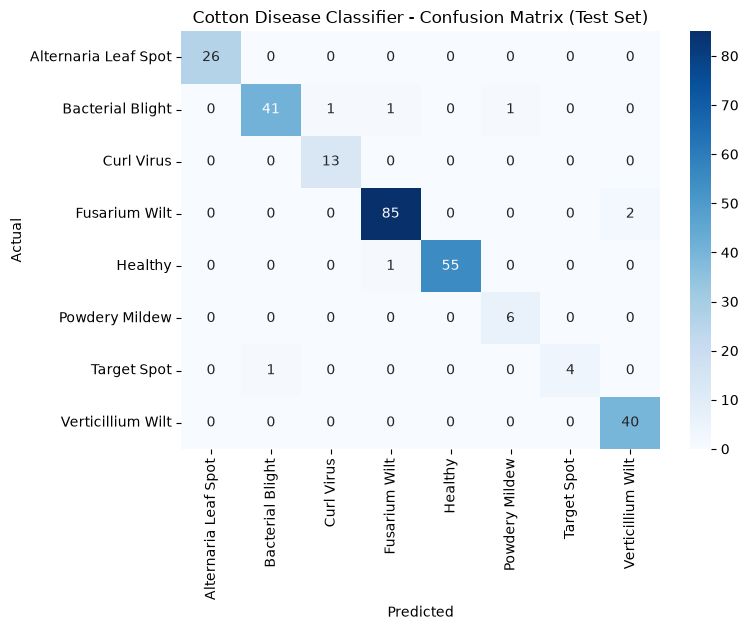

Saved: confusion_matrix_Cotton.png

==================== Groundnut ====================
                      precision    recall  f1-score   support

Alternaria Leaf Spot      0.950     0.983     0.966        58
             Healthy      0.900     0.947     0.923       228
           Leaf Spot      0.937     0.908     0.922       294
Nutrition Deficiency      0.978     0.918     0.947        49
             Rosette      1.000     1.000     1.000        14
                Rust      0.920     0.885     0.902        52

            accuracy                          0.928       695
           macro avg      0.948     0.940     0.943       695
        weighted avg      0.929     0.928     0.928       695

Macro-F1: 0.9435


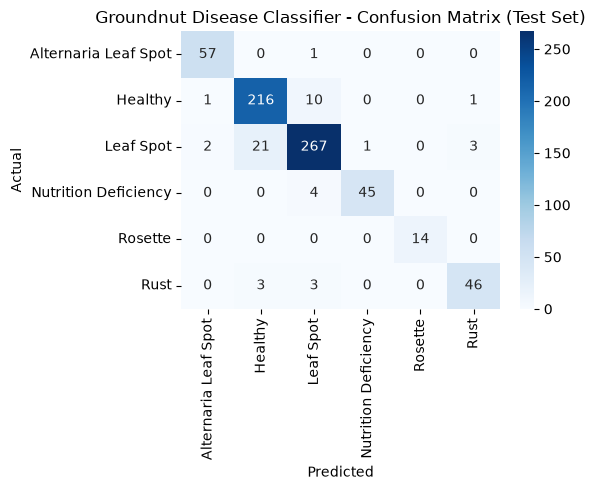

Saved: confusion_matrix_Groundnut.png

==================== Pepper Bell ====================
                      precision    recall  f1-score   support

      Bacterial Spot      0.998     1.000     0.999       536
Cercospora Leaf Spot      1.000     0.986     0.993       211
               Edema      1.000     0.800     0.889         5
             Healthy      0.991     0.987     0.989       226
           Leaf Curl      1.000     0.981     0.990        52
 Nutrient Deficiency      0.937     1.000     0.967        59
      Powdery Mildew      0.964     1.000     0.982        27

            accuracy                          0.993      1116
           macro avg      0.984     0.965     0.973      1116
        weighted avg      0.993     0.993     0.993      1116

Macro-F1: 0.9727


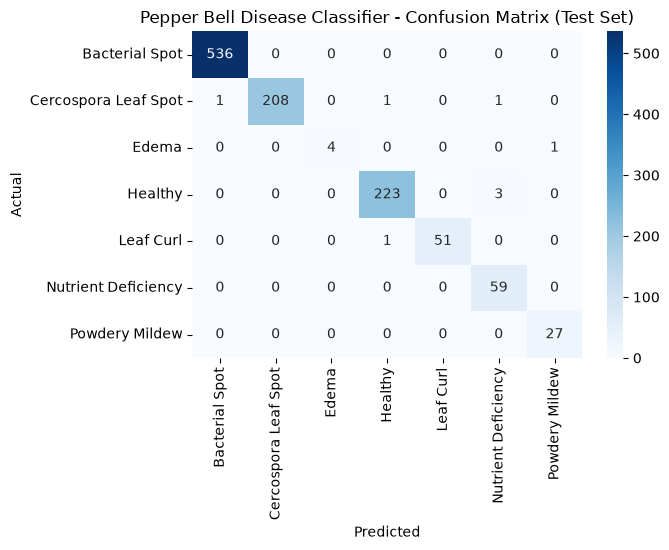

Saved: confusion_matrix_Pepper_Bell.png

==================== Potato ====================
              precision    recall  f1-score   support

    Bacteria      0.902     0.988     0.943        84
Early Blight      0.993     1.000     0.996       266
       Fungi      0.855     0.909     0.881       110
     Healthy      0.987     0.987     0.987       224
 Late Blight      0.989     0.959     0.974       290
    Nematode      0.889     0.800     0.842        10
        Pest      0.904     0.833     0.867        90
       Virus      0.910     0.910     0.910        78

    accuracy                          0.957      1152
   macro avg      0.929     0.923     0.925      1152
weighted avg      0.957     0.957     0.957      1152

Macro-F1: 0.9250


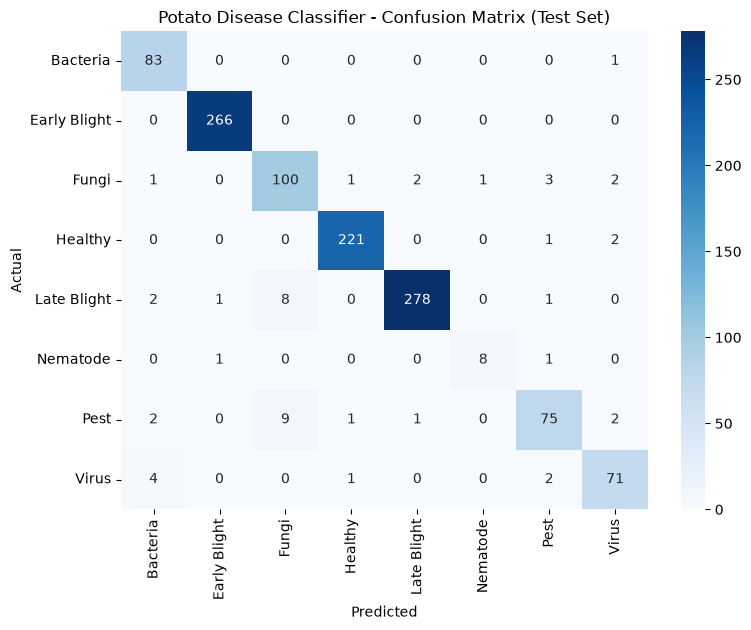

Saved: confusion_matrix_Potato.png

==================== Tomato ====================
                   precision    recall  f1-score   support

   Bacterial Spot      0.940     0.945     0.943       183
     Early Blight      0.936     0.936     0.936       220
          Healthy      0.943     0.971     0.957       206
      Late Blight      0.939     0.934     0.937       166
        Mold Leaf      0.896     0.920     0.908        75
     Mosaic Virus      0.667     0.462     0.545        13
         Septoria      0.800     0.800     0.800        45
Yellow Curl Virus      0.882     0.714     0.789        21

         accuracy                          0.926       929
        macro avg      0.876     0.835     0.852       929
     weighted avg      0.924     0.926     0.925       929

Macro-F1: 0.8519


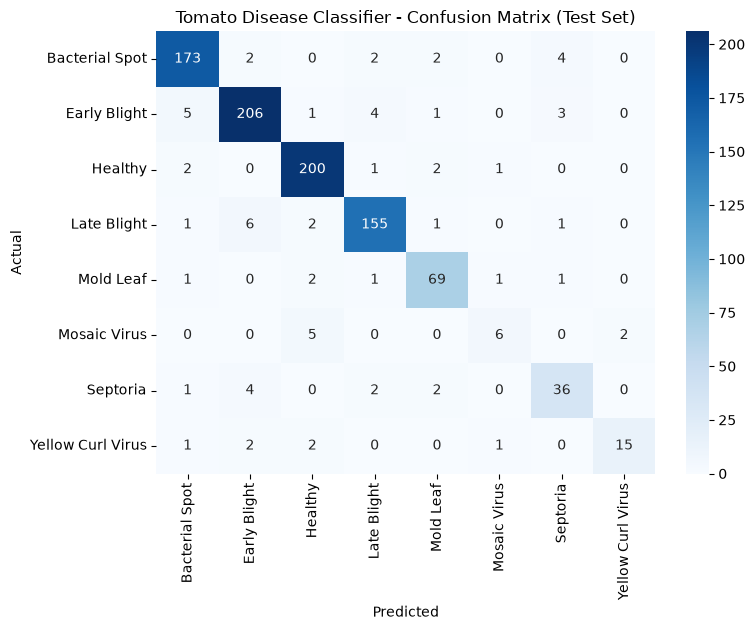

Saved: confusion_matrix_Tomato.png

==================== Summary ====================
Cotton          macro-F1: 0.9590
Groundnut       macro-F1: 0.9435
Pepper Bell     macro-F1: 0.9727
Potato          macro-F1: 0.9250
Tomato          macro-F1: 0.8519


: 

In [ ]:
evaluate_all_trained_crops()